In [1]:
import sys
sys.path.insert(0, ".")


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from src.models.ml_models import (
    prepare_ml_data,
    time_series_split,
    train_lightgbm,
    train_xgboost,
    train_catboost,
    train_random_forest,
    ensemble_predictions
)
from src.models.feature_importance import plot_feature_importance
from src.evaluation.metrics import evaluate_all, metrics_dataframe

print("All imports done!")

All imports done!


In [2]:
df = pd.read_parquet("data/processed/train_features.parquet")

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

Shape: (408436, 46)
Columns: ['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday', 'Type', 'Size', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment', 'Month', 'WeekOfYear', 'month', 'week_of_year', 'quarter', 'year', 'day_of_year', 'is_december', 'is_q4', 'year_progress', 'lag_1', 'lag_2', 'lag_4', 'lag_8', 'lag_12', 'lag_26', 'lag_52', 'rolling_mean_4', 'rolling_std_4', 'rolling_mean_8', 'rolling_std_8', 'rolling_mean_12', 'rolling_std_12', 'rolling_mean_26', 'rolling_std_26', 'rolling_max_4', 'rolling_min_4', 'is_holiday', 'weeks_to_next_holiday', 'weeks_from_last_holiday']


In [3]:
print("Splitting data...")
train_df, test_df = time_series_split(df, test_weeks=12)

print(f"\nTrain rows: {len(train_df)}")
print(f"Test rows:  {len(test_df)}")

Splitting data...
Train: 2010-03-05 → 2012-08-03 (372898 rows)
Test:  2012-08-10 → 2012-10-26 (35538 rows)

Train rows: 372898
Test rows:  35538


In [4]:
X_train, y_train = prepare_ml_data(train_df)
X_test,  y_test  = prepare_ml_data(test_df)

print("X_train shape:", X_train.shape)
print("X_test shape: ", X_test.shape)
print("\nFeatures used:")
for col in X_train.columns:
    print(" ", col)

X_train shape: (372898, 44)
X_test shape:  (35538, 44)

Features used:
  Store
  Dept
  IsHoliday
  Type
  Size
  Temperature
  Fuel_Price
  MarkDown1
  MarkDown2
  MarkDown3
  MarkDown4
  MarkDown5
  CPI
  Unemployment
  Month
  WeekOfYear
  month
  week_of_year
  quarter
  year
  day_of_year
  is_december
  is_q4
  year_progress
  lag_1
  lag_2
  lag_4
  lag_8
  lag_12
  lag_26
  lag_52
  rolling_mean_4
  rolling_std_4
  rolling_mean_8
  rolling_std_8
  rolling_mean_12
  rolling_std_12
  rolling_mean_26
  rolling_std_26
  rolling_max_4
  rolling_min_4
  is_holiday
  weeks_to_next_holiday
  weeks_from_last_holiday


In [5]:
print("=" * 50)
print("MODEL 1 — LightGBM")
print("=" * 50)

lgb_model, lgb_preds, lgb_metrics = train_lightgbm(
    X_train, y_train, X_test, y_test
)

MODEL 1 — LightGBM
  Training LightGBM...
  LightGBM — RMSE: 2734.32 | MAPE: 1014.42% | R2: 0.9844


In [6]:
print("=" * 50)
print("MODEL 2 — XGBoost")
print("=" * 50)

xgb_model, xgb_preds, xgb_metrics = train_xgboost(
    X_train, y_train, X_test, y_test
)

MODEL 2 — XGBoost
  Training XGBoost...
  XGBoost    — RMSE: 2577.95 | MAPE: 1122.80% | R2: 0.9862


In [7]:
print("=" * 50)
print("MODEL 3 — CatBoost")
print("=" * 50)

cat_model, cat_preds, cat_metrics = train_catboost(
    X_train, y_train, X_test, y_test
)

MODEL 3 — CatBoost
  Training CatBoost...
  CatBoost   — RMSE: 2769.90 | MAPE: 1340.42% | R2: 0.9840


In [8]:
print("=" * 50)
print("MODEL 4 — Random Forest")
print("=" * 50)

rf_model, rf_preds, rf_metrics = train_random_forest(
    X_train, y_train, X_test, y_test
)

MODEL 4 — Random Forest
  Training Random Forest...
  Random Forest — RMSE: 2741.23 | MAPE: 823.82% | R2: 0.9843


In [9]:
print("=" * 50)
print("ENSEMBLE — Combining All Models")
print("=" * 50)

all_predictions = {
    "LightGBM":     lgb_preds,
    "XGBoost":      xgb_preds,
    "CatBoost":     cat_preds,
    "RandomForest": rf_preds,
}

# Simple average ensemble
ensemble_preds   = ensemble_predictions(all_predictions)
ensemble_metrics = evaluate_all(y_test, ensemble_preds)

print(f"Ensemble — RMSE: {ensemble_metrics['RMSE']:.2f} | "
      f"MAPE: {ensemble_metrics['MAPE']:.2f}% | "
      f"R2: {ensemble_metrics['R2']:.4f}")

ENSEMBLE — Combining All Models
Ensemble — RMSE: 2615.55 | MAPE: 1074.34% | R2: 0.9857


In [10]:
print("=" * 60)
print("FULL MODEL COMPARISON")
print("=" * 60)

all_results = {
    "LightGBM":     lgb_metrics,
    "XGBoost":      xgb_metrics,
    "CatBoost":     cat_metrics,
    "Random Forest": rf_metrics,
    "Ensemble":     ensemble_metrics,
}

results_table = metrics_dataframe(all_results)
print(results_table.to_string())

best_model = results_table.index[0]
print(f"\nBest model: {best_model}")

FULL MODEL COMPARISON
                     MAE       RMSE       MAPE    SMAPE      R2
Model                                                          
XGBoost        1234.4037  2577.9547  1122.8022  22.5566  0.9862
Ensemble       1254.0585  2615.5453  1074.3352  22.2820  0.9857
LightGBM       1305.2063  2734.3211  1014.4189  23.6317  0.9844
Random Forest  1294.5076  2741.2303   823.8171  18.3158  0.9843
CatBoost       1360.2422  2769.8996  1340.4248  24.5384  0.9840

Best model: XGBoost


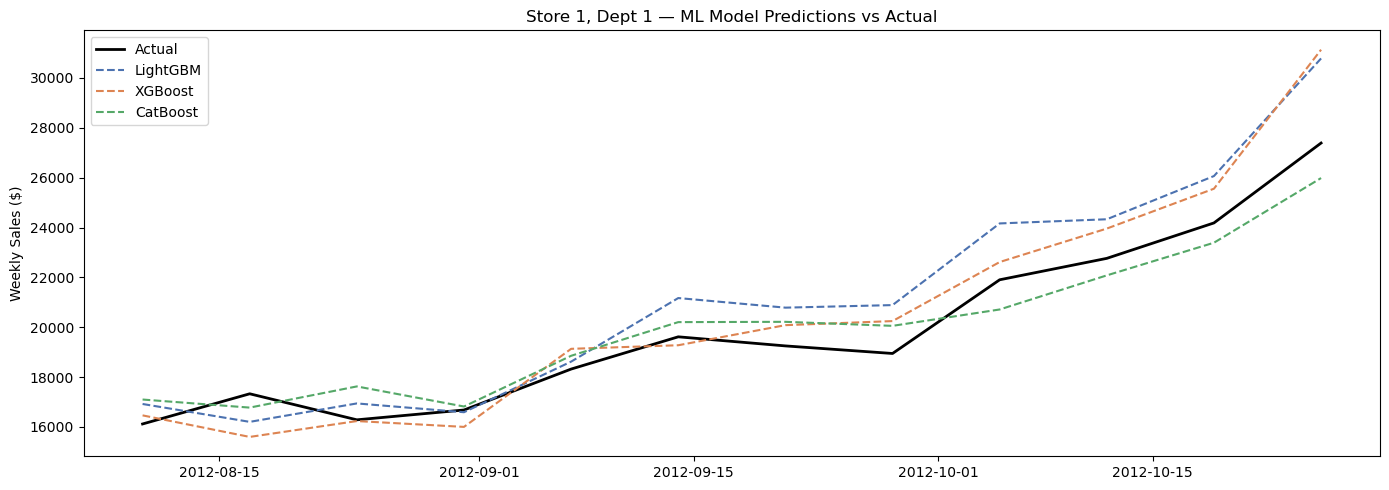

In [11]:
# Use one store-dept for a clean visual
store, dept = 1, 1

test_sample = test_df[
    (test_df["Store"] == store) &
    (test_df["Dept"]  == dept)
].sort_values("Date")

# Get predictions for just this store-dept
sample_idx = test_sample.index

# Reindex predictions to match
X_sample = X_test.loc[sample_idx]

lgb_sample = lgb_model.predict(X_sample)
xgb_sample = xgb_model.predict(X_sample)
cat_sample = cat_model.predict(X_sample)

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(test_sample["Date"], test_sample["Weekly_Sales"],
        label="Actual", color="black", linewidth=2)

ax.plot(test_sample["Date"], lgb_sample,
        label="LightGBM", color="#4C72B0", linewidth=1.5, linestyle="--")

ax.plot(test_sample["Date"], xgb_sample,
        label="XGBoost", color="#DD8452", linewidth=1.5, linestyle="--")

ax.plot(test_sample["Date"], cat_sample,
        label="CatBoost", color="#55A868", linewidth=1.5, linestyle="--")

ax.set_title(f"Store {store}, Dept {dept} — ML Model Predictions vs Actual")
ax.set_ylabel("Weekly Sales ($)")
ax.legend()
plt.tight_layout()
plt.savefig("reports/figures/10_ml_predictions.png", dpi=150, bbox_inches="tight")
plt.show()

LightGBM Feature Importance:


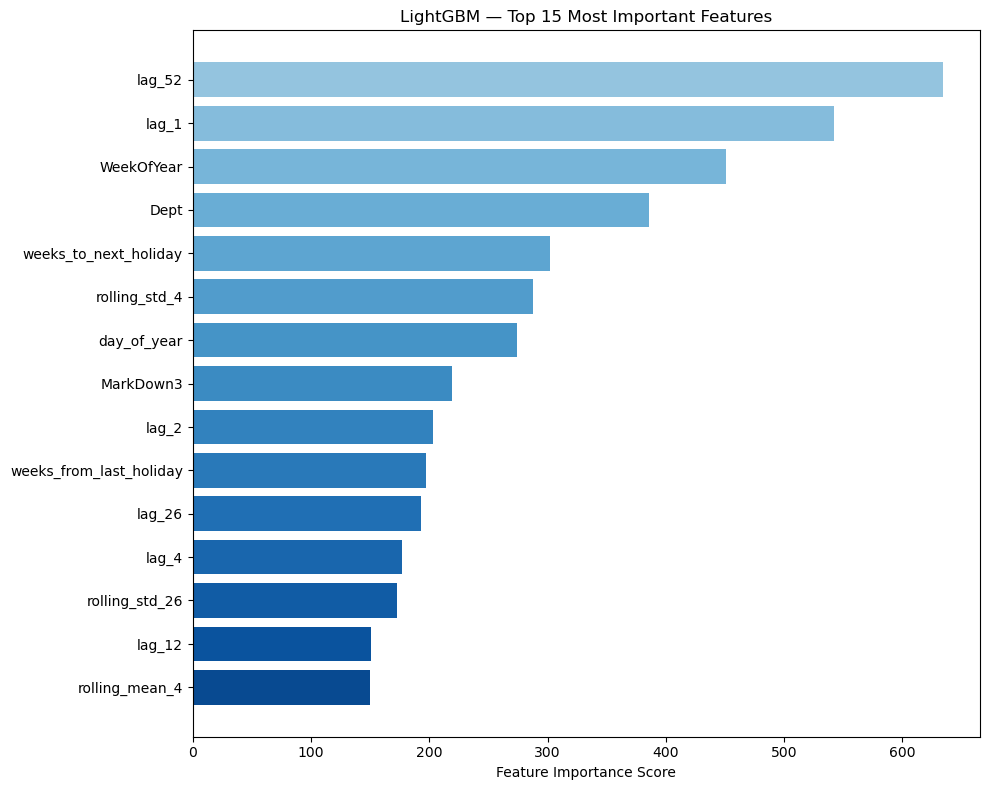


Top 10 features for LightGBM:
  lag_52                         634.0000
  lag_1                          542.0000
  WeekOfYear                     451.0000
  Dept                           386.0000
  weeks_to_next_holiday          302.0000
  rolling_std_4                  288.0000
  day_of_year                    274.0000
  MarkDown3                      219.0000
  lag_2                          203.0000
  weeks_from_last_holiday        197.0000


,feature,importance
30,lag_52,634
24,lag_1,542
15,WeekOfYear,451
1,Dept,386
42,weeks_to_next_holiday,302
32,rolling_std_4,288
20,day_of_year,274
9,MarkDown3,219
25,lag_2,203
43,weeks_from_last_holiday,197


In [12]:
feature_names = X_train.columns.tolist()

print("LightGBM Feature Importance:")
plot_feature_importance(lgb_model, feature_names, model_name="LightGBM", top_n=15)

In [13]:
import joblib
import json
import os

os.makedirs("models/saved", exist_ok=True)
os.makedirs("reports/metrics", exist_ok=True)

# Save trained models (so you don't need to retrain later)
joblib.dump(lgb_model, "models/saved/lightgbm.pkl")
joblib.dump(xgb_model, "models/saved/xgboost.pkl")
joblib.dump(cat_model, "models/saved/catboost.pkl")
joblib.dump(rf_model,  "models/saved/random_forest.pkl")

print("Models saved to models/saved/")

# Save metrics
with open("reports/metrics/phase5_results.json", "w") as f:
    json.dump(all_results, f, indent=4)

print("Metrics saved to reports/metrics/phase5_results.json")

print("\n" + "=" * 50)
print("PHASE 5 COMPLETE!")
print("=" * 50)
print(f"Best model: {best_model}")
print(f"Best RMSE:  {results_table['RMSE'].iloc[0]:.2f}")
print(f"Best MAPE:  {results_table['MAPE'].iloc[0]:.2f}%")
print(f"Best R2:    {results_table['R2'].iloc[0]:.4f}")

Models saved to models/saved/
Metrics saved to reports/metrics/phase5_results.json

PHASE 5 COMPLETE!
Best model: XGBoost
Best RMSE:  2577.95
Best MAPE:  1122.80%
Best R2:    0.9862
